# AnyLogic: Job Shop y Lead Acid Battery Production

Modelos propios siguiendo las guías oficiales. Las simulaciones se ejecutaron en AnyLogic PLE 8.9.10; este notebook analiza sus CSV. Se conserva el trabajo previo de Bank Office y se excluyen los tutoriales 2 y 3.

20 réplicas por modelo; semillas 160005011–160005030. Job Shop: 8 horas. Baterías: 4 horas, dentro del límite de 5 horas de Material Handling en PLE. Estado inicial vacío; sin calentamiento. Los IC son para las medias transitorias entre réplicas.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image
root = Path.cwd()
if not (root / 'datos' / 'anylogic').exists():
    root = root / 'lab_4'
data = root / 'datos' / 'anylogic'
replicas = pd.read_csv(data / 'todas_las_replicas.csv')
resumen = pd.read_csv(data / 'resumen_ic95.csv')
display(resumen)


,model,metric,n,mean,sd,ci_low,ci_high,half_width
0,job_shop,good,20,445.250000,4.363425,443.207854,447.292146,2.042146
1,job_shop,good_per_hour,20,55.656250,0.545428,55.400982,55.911518,0.255268
2,job_shop,cycle_minutes,20,57.124492,2.261157,56.066238,58.182746,1.058254
3,job_shop,mean_wip,20,57.311952,2.125759,56.317066,58.306838,0.994886
4,job_shop,wip,20,34.750000,4.363425,32.707854,36.792146,2.042146
5,job_shop,utilization_percent,20,95.829060,0.171082,95.748991,95.909129,0.080069
6,battery,good,20,33.400000,4.706099,31.197478,35.602522,2.202522
7,battery,good_per_hour,20,8.350000,1.176525,7.799369,8.900631,0.550631
8,battery,cycle_minutes,20,21.119094,8.154574,17.302636,24.935552,3.816458
9,battery,mean_wip,20,3.282625,1.730917,2.472531,4.092719,0.810094


In [2]:
for model, df in replicas.groupby('model'):
    assert len(df) == 20 and df.seed.is_unique
    assert (df.entered == df.completed + df.wip).all()
    assert (df.completed == df.good + df.defective).all()
    expected = 14400 if model == 'battery' else 480
    assert (df.horizon == expected).all()
    print(model, ': 20 réplicas; horizonte y balances correctos')


battery : 20 réplicas; horizonte y balances correctos
job_shop : 20 réplicas; horizonte y balances correctos


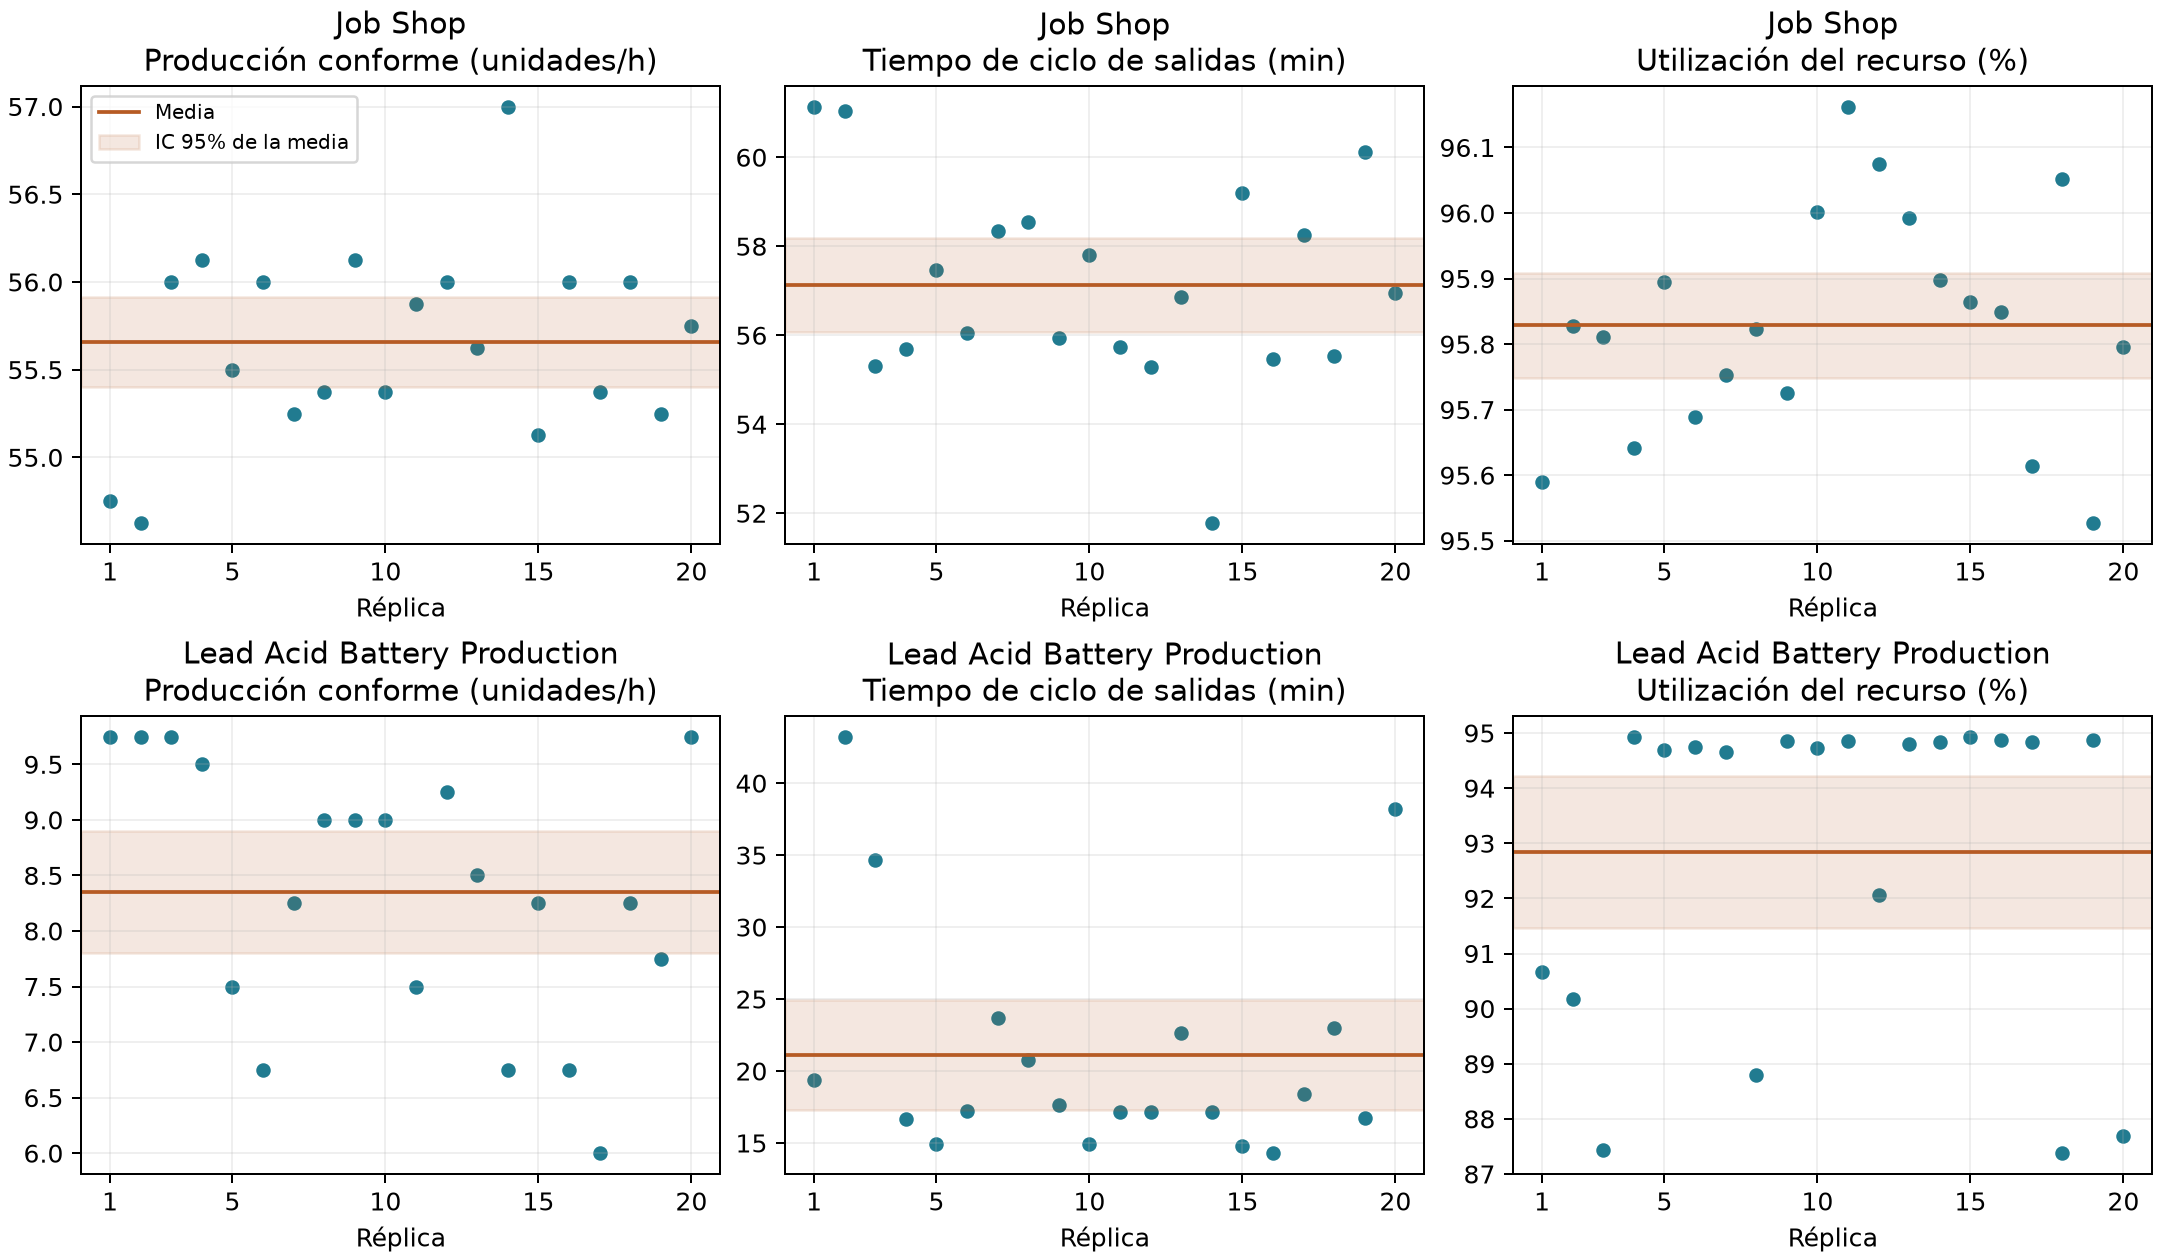

# Estadística de los modelos AnyLogic

Datos obtenidos en el experimento nativo `Estadistica` de cada modelo. Python solo analiza los CSV exportados.

20 réplicas independientes por modelo, semillas 160005011–160005030 y estado inicial vacío. Job Shop: 8 horas; baterías: 4 horas. AnyLogic PLE limita Material Handling a 5 horas. Se mantienen las tasas y tiempos de la guía. El curado de baterías dura 2 minutos, como en el tutorial; no representa el tiempo industrial de 12–24 horas.

El IC de la media es media ± t(0.975,19) × desviación muestral / √20. Las réplicas, y no los agentes individuales, son la unidad estadística.

| Modelo | Medida | Media | Desv. estándar | IC 95% |
|---|---|---:|---:|---:|
| Job Shop | Producción conforme (unidades/horizonte) | 445.250 | 4.363 | [443.208, 447.292] |
| Job Shop | Producción conforme (unidades/h) | 55.656 | 0.545 | [55.401, 55.912] |
| Job Shop | Ciclo de salidas (min) | 57.124 | 2.261 | [56.066, 58.183] |
| Job Shop | WIP medio (unidades) | 57.312 | 2.126 | [56.317, 58.307] |
| Job Shop | WIP final (unidades) | 34.750 | 4.363 | [32.708, 36.792] |
| Job Shop | Utilización del recurso (%) | 95.829 | 0.171 | [95.749, 95.909] |
| Lead Acid Battery Production | Producción conforme (unidades/horizonte) | 33.400 | 4.706 | [31.197, 35.603] |
| Lead Acid Battery Production | Producción conforme (unidades/h) | 8.350 | 1.177 | [7.799, 8.901] |
| Lead Acid Battery Production | Ciclo de salidas (min) | 21.119 | 8.155 | [17.303, 24.936] |
| Lead Acid Battery Production | WIP medio (unidades) | 3.283 | 1.731 | [2.473, 4.093] |
| Lead Acid Battery Production | WIP final (unidades) | 3.600 | 2.927 | [2.230, 4.970] |
| Lead Acid Battery Production | Utilización del recurso (%) | 92.841 | 2.950 | [91.461, 94.222] |

En baterías se observaron 3 rechazos entre 671 salidas (0.447 %). El intervalo de Wilson 95 % del porcentaje agrupado es [0.152, 1.306] %. Este intervalo usa el supuesto binomial por unidad y no es el IC t de medias entre réplicas. Con tan pocos rechazos no permite una validación precisa del 1 % configurado.

El tiempo de ciclo incluye la espera desde la salida de Source hasta Sink. En baterías se mide desde la admisión de la caja. Se promedian únicamente los agentes que salen antes del horizonte de su modelo; los pendientes no se cuentan como terminados. WIP medio es la integral temporal exacta del número admitido aún presente, dividida por el horizonte.

La utilización corresponde al conjunto de dos CNC en Job Shop y al operador de ensamblaje en baterías. Es la utilización registrada por ResourcePool: incluye el tiempo durante el cual el recurso está reservado, y no solo el tiempo de procesamiento. En Job Shop el CNC se reserva antes de recuperar el pallet del rack. El rendimiento conforme excluye los rechazos. Son resultados transitorios desde vacío, sin calentamiento; no son estimaciones de régimen estacionario. Los horizontes distintos impiden una comparación directa entre ambos procesos.

Se verificó en todas las réplicas: entradas = salidas + WIP final y salidas = conformes + rechazadas. Las 40 corridas alcanzaron el horizonte completo y usaron 20 semillas diferentes por modelo.

Job Shop recibe 480 pallets por jornada y termina en promedio 445.25: quedan 34.75 pendientes. La alta utilización de CNC debe interpretarse con su política de reserva durante el transporte. Baterías entrega en promedio 33.4 unidades conformes en cuatro horas, frente a una llegada nominal de 40 cajas. La variación entre réplicas es mayor en baterías, especialmente en el tiempo de ciclo; el IC de la producción por hora tiene semiancho de 0.551 unidades/h, frente a 0.255 en Job Shop.

![Réplicas e intervalos](../imagenes/anylogic/estadistica_ic95.png)


In [3]:
display(Image(filename=str(root / 'imagenes' / 'anylogic' / 'estadistica_ic95.png')))
display(Markdown((root / 'anylogic_models' / 'ESTADISTICA.md').read_text(encoding='utf8')))


El ciclo de baterías comienza con la admisión de la caja, no con la preparación del electrodo. Solo se incluyen ciclos de agentes terminados; los restantes se registran como WIP. La utilización de recursos incluye tiempo reservado. Los horizontes diferentes impiden una comparación directa de los dos procesos.

Para recalcular a partir de los CSV individuales, ejecutar `anylogic_models/analyze_statistics.py`. Para generar nuevas réplicas, abrir cada `.alp` en AnyLogic y ejecutar `Estadistica`. No se ejecuta un sustituto del modelo en Python.
